# 胎压融合爆胎检测：模拟数据测试

这个示例构造 4.2 秒、100 Hz 的四轮轮速数据：

- `FR + RL` 提供胎压信号，并始终确认正常；
- `FL + RR` 由轮速算法检测；
- 2.40 秒时模拟 `RR` 轮速持续增加 1.1%；
- 数据中同时加入共同加速和一阶转弯扰动。

测试预期只有 `RR` 报警，且报警来源是 `wheel_speed_confirmed`。数据生成和检测只使用 Python 标准库和项目代码；最后一个交互图复用项目的 Plotly display。

In [1]:
from wavelet_shape_blowout_detector import (
    PressureFusionBlowoutDetector,
    PressureFusionConfig,
    PressureFusionFrame,
)

WHEEL_NAMES = ("FL", "FR", "RL", "RR")
SAMPLE_RATE_HZ = 100
EVENT_TIME_S = 2.40
TOTAL_TIME_S = 4.20
RR_SPEED_GAIN = 0.011  # 1.1%

config = PressureFusionConfig(
    baseline_min_samples=120,
    baseline_window=300,
    confirm_frames=60,
    persistence_tail_frames=35,
)
detector = PressureFusionBlowoutDetector(config)

## 生成数据并逐帧送入检测器

`common_speed` 模拟整车缓慢加速，`turn` 模拟转弯时左右轮的反向变化。事件发生后只给 `RR` 叠加持续偏快。

In [2]:
results = []
simulated_wheels = []
frame_count = int(TOTAL_TIME_S * SAMPLE_RATE_HZ)
event_index = int(EVENT_TIME_S * SAMPLE_RATE_HZ)

for index in range(frame_count):
    t_sec = index / SAMPLE_RATE_HZ

    # 四轮共同的缓慢加速。
    common_speed = 50.0 + min(index, 250) * 0.01

    # 左轮略快、右轮略慢，模拟逐渐进入弯道。
    turn = 0.0015 * max(0, min(index - 150, 80))
    wheels = [
        common_speed + turn,  # FL
        common_speed - turn,  # FR
        common_speed + turn,  # RL
        common_speed - turn,  # RR
    ]

    if index >= event_index:
        wheels[3] *= 1.0 + RR_SPEED_GAIN

    # FR、RL 是胎压参考对角；False 表示胎压明确正常。
    pressure_blowouts = [None, False, False, None]
    frame = PressureFusionFrame.from_sequences(
        t_sec, wheels, pressure_blowouts
    )
    simulated_wheels.append(tuple(wheels))
    results.append(detector.push(frame))

print(f"已回放 {len(results)} 帧模拟数据。")

已回放 420 帧模拟数据。


## 查看结果并自动校验

下面寻找首次新报警，并用断言检查轮位、来源、事件前误报和检测延迟。修改上面的事件幅度或配置后，可以重新运行本单元观察测试是否仍通过。

In [3]:
first_alarm = next(
    result for result in results if any(result.new_blowouts)
)
alarm_wheels = [
    name
    for name, active in zip(WHEEL_NAMES, results[-1].blowout_alarms)
    if active
]
rr_onset = first_alarm.estimated_onset_times_s[3]
alarm_delay = first_alarm.t_sec - EVENT_TIME_S

print("胎压参考对角:", results[-1].sensor_diagonal)
print("轮速检测对角:", results[-1].speed_diagonal)
print("最终报警轮位:", alarm_wheels)
print("报警来源:", results[-1].alarm_sources)
print(f"模拟事件时刻: {EVENT_TIME_S:.2f} s")
print(f"估计事件时刻: {rr_onset:.2f} s")
print(f"确认报警时刻: {first_alarm.t_sec:.2f} s")
print(f"确认延迟: {alarm_delay:.2f} s")

assert not any(
    any(result.blowout_alarms)
    for result in results[:event_index]
), "事件前不应出现误报"
assert results[-1].sensor_diagonal == ("FR", "RL")
assert results[-1].speed_diagonal == ("FL", "RR")
assert results[-1].blowout_alarms == (False, False, False, True)
assert results[-1].alarm_sources[3] == "wheel_speed_confirmed"
assert rr_onset is not None and abs(rr_onset - EVENT_TIME_S) <= 0.15
assert 0.5 <= alarm_delay <= 1.1

print("✅ 模拟数据测试通过：仅 RR 被轮速算法确认。")

胎压参考对角: ('FR', 'RL')
轮速检测对角: ('FL', 'RR')
最终报警轮位: ['RR']
报警来源: ('none', 'none', 'none', 'wheel_speed_confirmed')
模拟事件时刻: 2.40 s
估计事件时刻: 2.37 s
确认报警时刻: 3.06 s
确认延迟: 0.66 s
✅ 模拟数据测试通过：仅 RR 被轮速算法确认。


## 检查事件附近的关键帧

每 0.2 秒输出一行，便于观察 RR 相对增益、对角增益、候选状态和报警状态的变化。

In [4]:
print(
    f"{'t/s':>5} {'RR速度':>9} {'RR增益/%':>10} "
    f"{'对角增益/%':>11} {'候选':>6} {'报警':>6}"
)
for index in range(event_index - 20, min(frame_count, event_index + 121), 20):
    result = results[index]
    rr_gain = result.individual_gains[3]
    diagonal_gain = result.diagonal_gain
    print(
        f"{result.t_sec:5.2f} {simulated_wheels[index][3]:9.3f} "
        f"{100 * rr_gain:10.3f} {100 * diagonal_gain:11.3f} "
        f"{str(result.candidates[3]):>6} "
        f"{str(result.blowout_alarms[3]):>6}"
    )

  t/s      RR速度     RR增益/%      对角增益/%     候选     报警
 2.20    52.095     -0.190       0.000  False  False
 2.40    52.855     -0.229       0.000  False  False
 2.60    52.956      0.865       1.094   True  False
 2.80    52.956      0.865       1.094   True  False
 3.00    52.956      0.865       1.094   True  False
 3.20    52.956      0.865       1.094  False   True
 3.40    52.956      0.865       1.094  False   True
 3.60    52.956      0.865       1.094  False   True


## 复用项目 Display 查看完整数据

这里直接复用 `pressure_fusion_display.py` 的 `build_figure`，不需要把模拟数据先写成 CSV。图中依次显示四轮轮速、逐轮/对角增益、上升沿证据，以及候选和锁存报警；支持悬停、拖动、滚轮缩放和底部范围条。

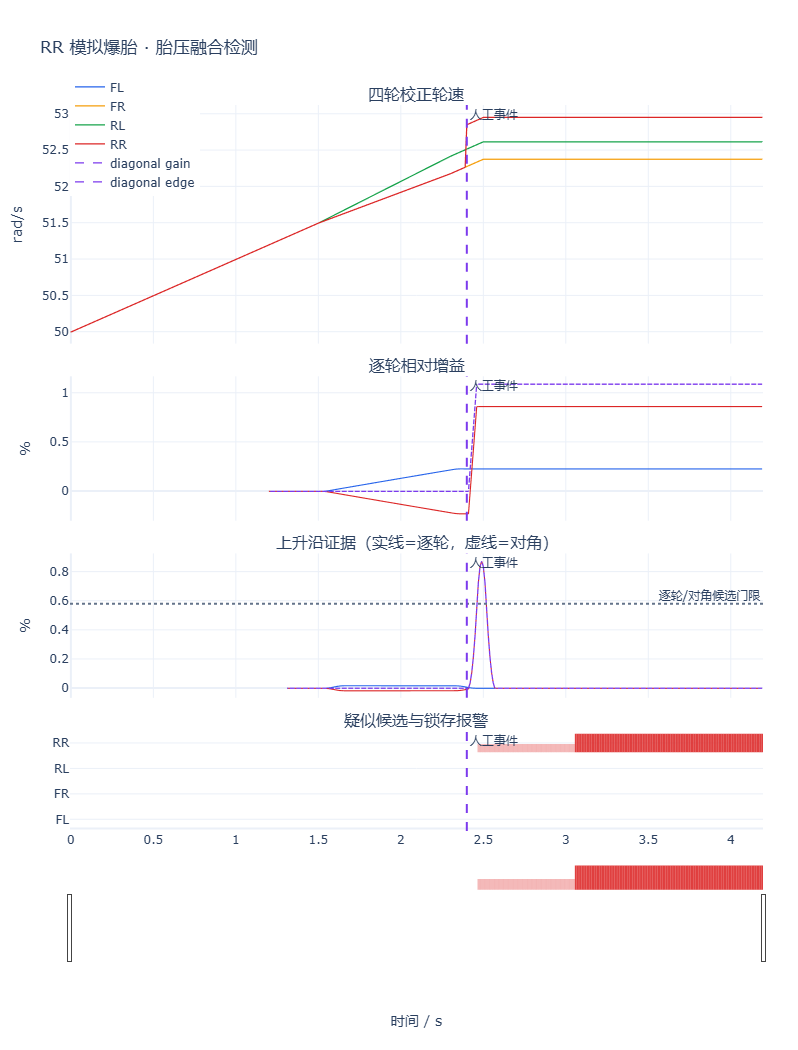

In [5]:
from wavelet_shape_blowout_detector.pressure_fusion_display import (
    PLOT_CONFIG,
    build_figure,
    window_data_from_results,
)

display_data = window_data_from_results(results)
figure = build_figure(
    display_data,
    config,
    event_time_s=EVENT_TIME_S,
    title="RR 模拟爆胎 · 胎压融合检测",
)
figure.show(config=PLOT_CONFIG)

## 未知胎压对角：运行时自动识别

检测器构造时不传入对角配置。下面用完全相同的检测代码覆盖两种实际硬件布局：

1. 胎压信号实际来自 `FL + RR`，在另一条对角模拟 `FR` 爆胎；
2. 胎压信号实际来自 `FR + RL`，在另一条对角模拟 `RR` 爆胎。

算法根据四轮输入中两个非 `None` 信号的位置自动发现胎压对角。模拟器当然要知道自己正在生成哪种硬件布局，但该布局不会传给检测器构造函数。

In [ ]:
UNKNOWN_LAYOUT_CASES = (
    {"actual_pressure_diagonal": (0, 3), "speed_target": 1},  # FL+RR -> FR
    {"actual_pressure_diagonal": (1, 2), "speed_target": 3},  # FR+RL -> RR
)


def run_unknown_diagonal_case(actual_pressure_diagonal, speed_target):
    # 注意：检测器只收到阈值配置，不接收胎压对角配置。
    case_detector = PressureFusionBlowoutDetector(config)
    case_results = []

    for index in range(frame_count):
        t_sec = index / SAMPLE_RATE_HZ
        common_speed = 50.0 + min(index, 250) * 0.01
        turn = 0.0015 * max(0, min(index - 150, 80))
        wheels = [
            common_speed + turn,
            common_speed - turn,
            common_speed + turn,
            common_speed - turn,
        ]
        if index >= event_index:
            wheels[speed_target] *= 1.0 + RR_SPEED_GAIN

        pressure_blowouts = [None] * 4
        for wheel_index in actual_pressure_diagonal:
            pressure_blowouts[wheel_index] = False

        case_results.append(
            case_detector.push(
                PressureFusionFrame.from_sequences(
                    t_sec, wheels, pressure_blowouts
                )
            )
        )
    return case_results


unknown_layout_results = {}
for case in UNKNOWN_LAYOUT_CASES:
    target = case["speed_target"]
    case_results = run_unknown_diagonal_case(**case)
    final = case_results[-1]
    first_alarm = next(
        result for result in case_results if any(result.new_blowouts)
    )
    expected_alarms = tuple(index == target for index in range(4))

    assert not any(
        any(result.blowout_alarms)
        for result in case_results[:event_index]
    )
    assert final.blowout_alarms == expected_alarms
    assert final.alarm_sources[target] == "wheel_speed_confirmed"
    assert WHEEL_NAMES[target] in final.speed_diagonal

    layout_name = "+".join(final.sensor_diagonal)
    unknown_layout_results[layout_name] = case_results
    print(
        f"自动识别 {layout_name:5s} 为胎压对角；"
        f"{WHEEL_NAMES[target]} 于 {first_alarm.t_sec:.2f} s 确认报警 ✅"
    )

In [ ]:
for layout_name, case_results in unknown_layout_results.items():
    final = case_results[-1]
    target_name = next(
        name
        for name, active in zip(WHEEL_NAMES, final.blowout_alarms)
        if active
    )
    case_figure = build_figure(
        window_data_from_results(case_results),
        config,
        event_time_s=EVENT_TIME_S,
        title=f"自动识别胎压对角 {layout_name} · {target_name} 模拟爆胎",
    )
    case_figure.show(config=PLOT_CONFIG)